In [18]:
from sklearn.tree import DecisionTreeClassifier

In [19]:
import pandas as pd
import numpy as np

In [20]:
# Load datasets
X_train = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\X_train.txt",
    sep=r"\s+",
    header=None
)

y_train = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\train\y_train.txt",
    header=None
)

X_test = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\test\X_test.txt",
    sep=r"\s+",
    header=None
)

y_test = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\test\y_test.txt",
    header=None
)

In [21]:
# Load feature names
features = pd.read_csv(
    r"D:\imu-har-exoskeleton-ai\data\UCI HAR Dataset\UCI HAR Dataset\features.txt",
    sep=r"\s+",
    header=None,
    names=["Index", "Feature"]
)

X_train.columns = features["Feature"]
X_test.columns = features["Feature"]

In [22]:
X_train.columns = [
    f"{col}_{i}" if X_train.columns.tolist().count(col) > 1 else col
    for i, col in enumerate(X_train.columns)
]

X_test.columns = X_train.columns

In [23]:
# Encode labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train[0])
y_test_encoded = label_encoder.transform(y_test[0])

In [24]:
# Create validation split
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_train_encoded
)

In [25]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

In [28]:
decision_tree.fit(
    X_train_final,
    y_train_final
)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [29]:
y_val_pred = decision_tree.predict(X_val)

print("Predicted Value:", y_val_pred)

Predicted Value: [0 0 5 ... 5 3 0]


In [30]:
accuracy = accuracy_score(y_val, y_val_pred)

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9367777022433719


In [31]:
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       245
           1       0.93      0.90      0.92       215
           2       0.92      0.93      0.92       197
           3       0.90      0.91      0.91       257
           4       0.92      0.91      0.91       275
           5       1.00      1.00      1.00       282

    accuracy                           0.94      1471
   macro avg       0.94      0.93      0.93      1471
weighted avg       0.94      0.94      0.94      1471



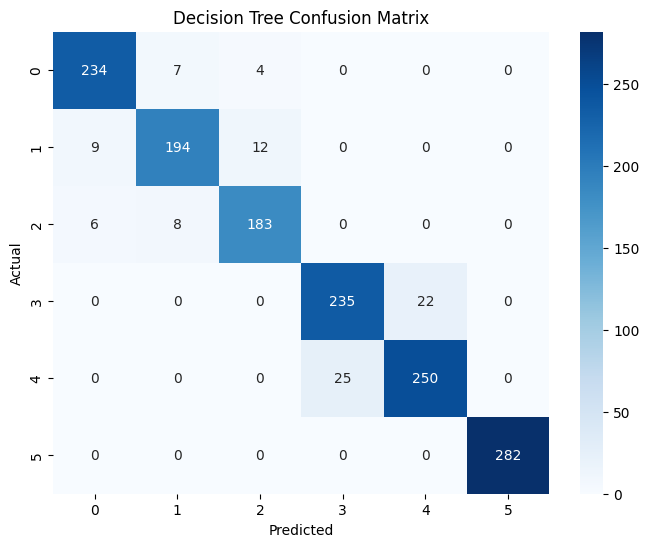

<Figure size 640x480 with 0 Axes>

In [65]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

plt.savefig(
    "../results/decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [35]:
random_forest.fit(
    X_train_final,
    y_train_final
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_val_pred_rf = random_forest.predict(X_val)

print("Predicted Value:", y_val_pred_rf)

Predicted Value: [0 0 5 ... 5 3 0]


In [37]:
rf_accuracy = accuracy_score(
    y_val,
    y_val_pred_rf
)

print("Random Forest Validation Accuracy:", rf_accuracy)

Random Forest Validation Accuracy: 0.981645139360979


In [38]:
print(classification_report(
    y_val,
    y_val_pred_rf
))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       245
           1       0.99      0.99      0.99       215
           2       0.98      0.98      0.98       197
           3       0.98      0.95      0.96       257
           4       0.95      0.98      0.97       275
           5       1.00      1.00      1.00       282

    accuracy                           0.98      1471
   macro avg       0.98      0.98      0.98      1471
weighted avg       0.98      0.98      0.98      1471



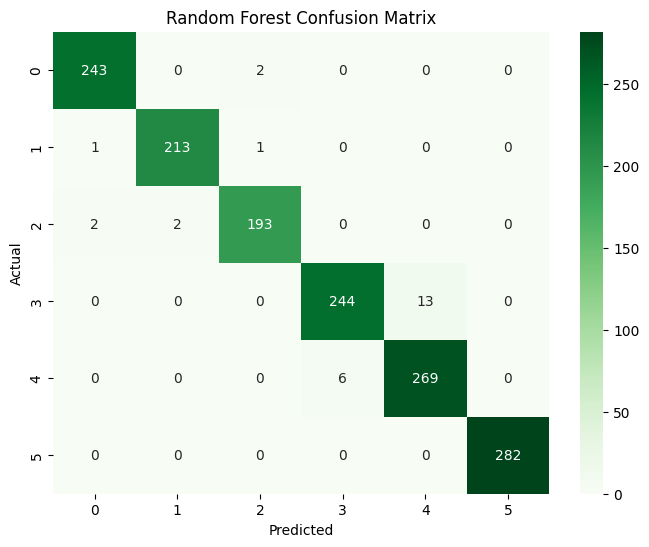

<Figure size 640x480 with 0 Axes>

In [66]:
cm_rf = confusion_matrix(
    y_val,
    y_val_pred_rf
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.savefig(
    "../visuals/random_forest_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

plt.savefig(
    "../results/random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

In [40]:
model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

print(model_comparison)

           Model  Accuracy
0  Decision Tree  0.936778
1  Random Forest  0.981645


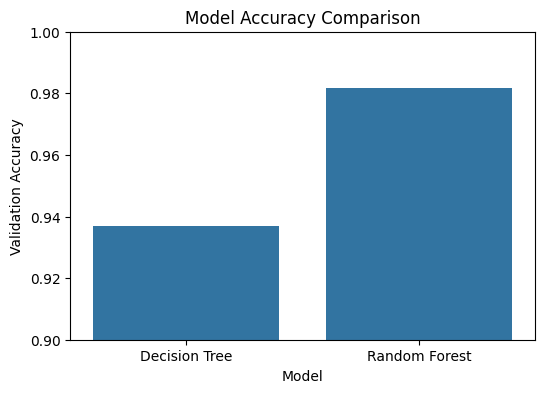

In [41]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.9, 1.0)

plt.title("Model Accuracy Comparison")
plt.ylabel("Validation Accuracy")

plt.savefig(
    "../visuals/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": random_forest.feature_importances_
})

In [43]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [44]:
feature_importance.head(20)

,Feature,Importance
40,tGravityAcc-mean()-X,0.034219
49,tGravityAcc-max()-X,0.033872
558,"angle(X,gravityMean)",0.031449
559,"angle(Y,gravityMean)",0.026073
41,tGravityAcc-mean()-Y,0.025603
56,tGravityAcc-energy()-X,0.023519
50,tGravityAcc-max()-Y,0.022912
52,tGravityAcc-min()-X,0.022427
53,tGravityAcc-min()-Y,0.020589
57,tGravityAcc-energy()-Y,0.015518


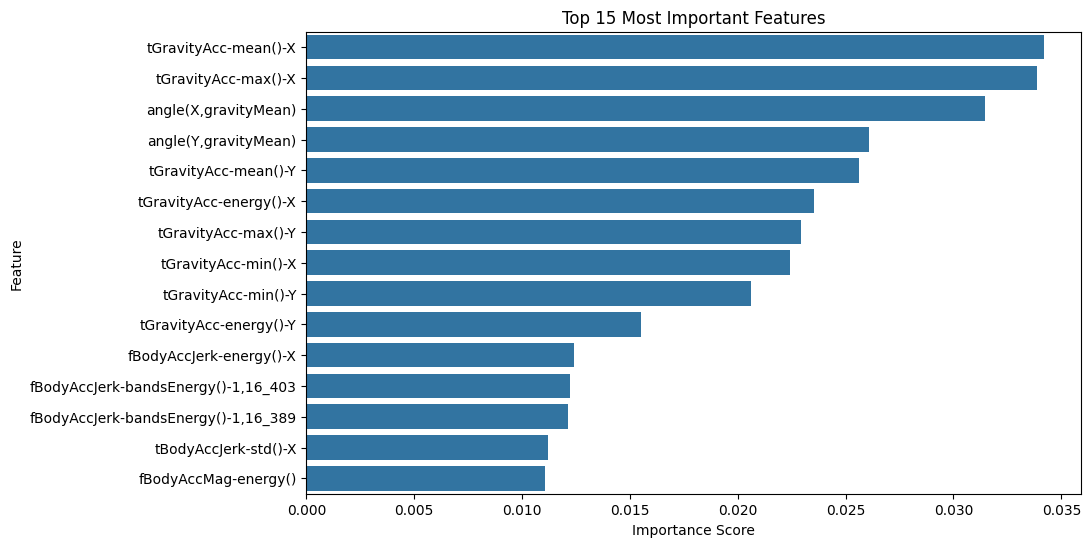

In [45]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.savefig(
    "../visuals/feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [46]:
from xgboost import XGBClassifier

In [47]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

In [48]:
X_train_np = X_train_final.to_numpy()
X_val_np = X_val.to_numpy()

xgb_model.fit(
    X_train_np,
    y_train_final
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [49]:
y_val_pred_xgb = xgb_model.predict(X_val_np)

In [50]:
xgb_accuracy = accuracy_score(
    y_val,
    y_val_pred_xgb
)

print("XGBoost Validation Accuracy:", xgb_accuracy)

XGBoost Validation Accuracy: 0.991162474507138


In [51]:
print(classification_report(
    y_val,
    y_val_pred_xgb
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       245
           1       1.00      1.00      1.00       215
           2       0.99      0.99      0.99       197
           3       1.00      0.96      0.98       257
           4       0.96      1.00      0.98       275
           5       1.00      1.00      1.00       282

    accuracy                           0.99      1471
   macro avg       0.99      0.99      0.99      1471
weighted avg       0.99      0.99      0.99      1471



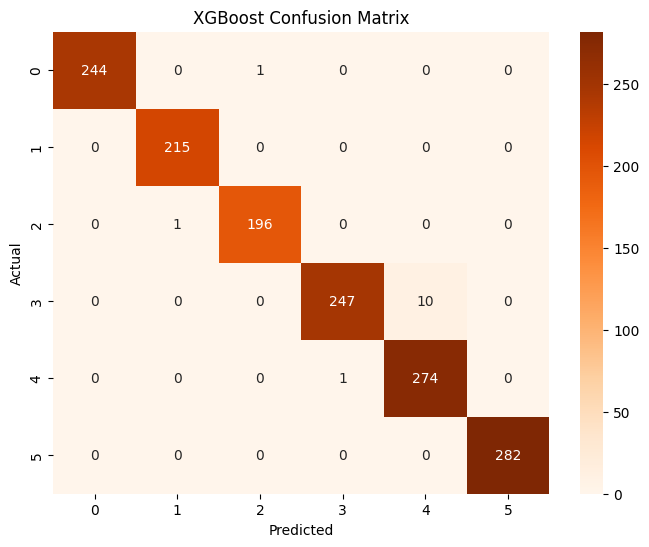

<Figure size 640x480 with 0 Axes>

In [67]:
cm_xgb = confusion_matrix(
    y_val,
    y_val_pred_xgb
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

plt.savefig(
    "../results/xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

In [53]:
comparison_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Decision Tree,0.936778
1,Random Forest,0.981645
2,XGBoost,0.991162


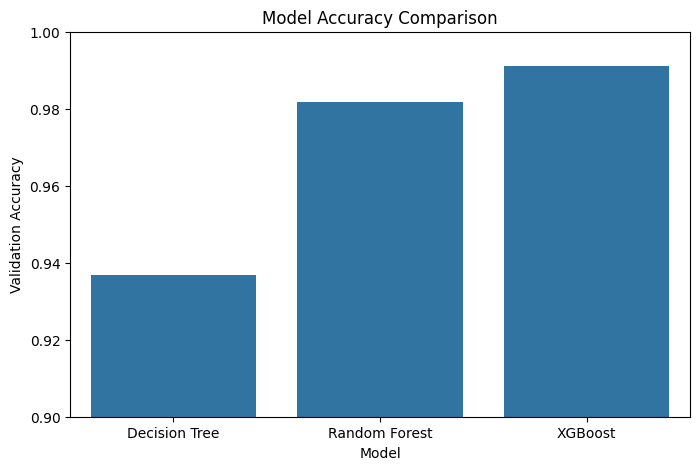

<Figure size 640x480 with 0 Axes>

In [64]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy"
)

plt.ylim(0.90, 1.00)

plt.title("Model Accuracy Comparison")
plt.ylabel("Validation Accuracy")

plt.show()

plt.savefig(
    "../results/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

In [55]:
print(
    "DT → RF Improvement:",
    round((rf_accuracy - accuracy) * 100, 2),
    "%"
)

print(
    "RF → XGB Improvement:",
    round((xgb_accuracy - rf_accuracy) * 100, 2),
    "%"
)

DT → RF Improvement: 4.49 %
RF → XGB Improvement: 0.95 %


In [56]:
#Extract XGBoost Feature Importance

xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

In [57]:
xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

In [58]:
xgb_importance.head(20)

,Feature,Importance
330,"fBodyAcc-bandsEnergy()-1,8_330",0.067192
52,tGravityAcc-min()-X,0.066113
504,fBodyAccMag-mad(),0.047965
166,tBodyGyroJerk-mad()-X,0.044905
518,fBodyBodyAccJerkMag-max(),0.039993
296,fBodyAcc-skewness()-X,0.028435
503,fBodyAccMag-std(),0.028091
559,"angle(Y,gravityMean)",0.027821
9,tBodyAcc-max()-X,0.025699
90,tBodyAccJerk-max()-Y,0.024868


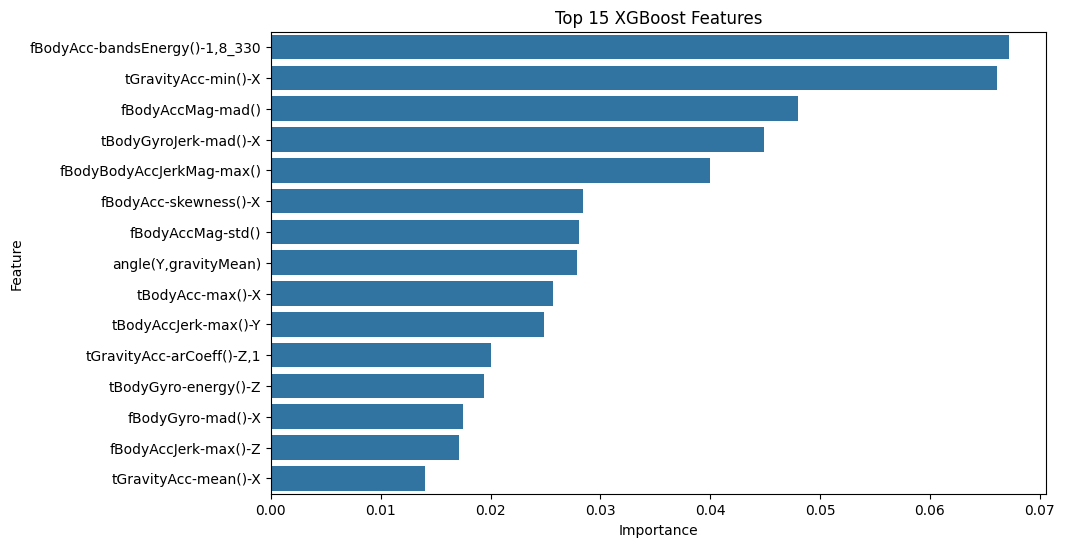

In [59]:
top_xgb_features = xgb_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_xgb_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 XGBoost Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [60]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

In [61]:
joblib.dump(
    random_forest,
    "../models/random_forest.pkl"
)

print("Random Forest saved.")

Random Forest saved.


In [62]:
joblib.dump(
    xgb_model,
    "../models/xgboost.pkl"
)

print("XGBoost saved.")

XGBoost saved.


In [63]:
joblib.dump(
    decision_tree,
    "../models/decision_tree.pkl"
)

print("Decision Tree saved.")

Decision Tree saved.
